In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore (1).csv


In [8]:
df = pd.read_csv("Sample - Superstore (1).csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

Shape: (9994, 21)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State   

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
print("Missing Values:")

df.isnull().sum()

Missing Values:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Duplicate Rows: 0
Shape after removing duplicates: (9994, 21)


In [13]:
print("========== MEAN ==========")
print(df.mean(numeric_only=True))

print("\n========== MEDIAN ==========")
print(df.median(numeric_only=True))

print("\n========== MODE ==========")
print(df.mode().iloc[0])

print("\n========== VARIANCE ==========")
print(df.var(numeric_only=True))

print("\n========== STANDARD DEVIATION ==========")
print(df.std(numeric_only=True))

========== MEAN ==========
Row ID          4997.500000
Postal Code    55190.379428
Sales            229.858001
Quantity           3.789574
Discount           0.156203
Profit            28.656896
dtype: float64

========== MEDIAN ==========
Row ID          4997.5000
Postal Code    56430.5000
Sales             54.4900
Quantity           3.0000
Discount           0.2000
Profit             8.6665
dtype: float64

========== MODE ==========
Row ID                         1
Order ID          CA-2017-100111
Order Date              9/5/2016
Ship Date             12/16/2015
Ship Mode         Standard Class
Customer ID             WB-21850
Customer Name      William Brown
Segment                 Consumer
Country            United States
City               New York City
State                 California
Postal Code              10035.0
Region                      West
Product ID       OFF-PA-10001970
Category         Office Supplies
Sub-Category             Binders
Product Name     Staple envelope


In [14]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Sales"] < lower) | (df["Sales"] > upper)]

print("Number of Outliers:", len(outliers))

outliers.head()

Number of Outliers: 1167


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
10,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
11,12,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,4,0.20,68.3568


In [15]:
df["Sales"] = np.where(df["Sales"] > upper, upper, df["Sales"])
df["Sales"] = np.where(df["Sales"] < lower, lower, df["Sales"])

print("Outliers treated successfully!")

Outliers treated successfully!


In [16]:
correlation = df.corr(numeric_only=True)

correlation

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.007105,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.008668,0.012761,0.058443,-0.029961
Sales,-0.007105,-0.008668,1.000000,0.265072,-0.060592,0.182907
Quantity,-0.004016,0.012761,0.265072,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.060592,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.182907,0.066253,-0.219487,1.000000


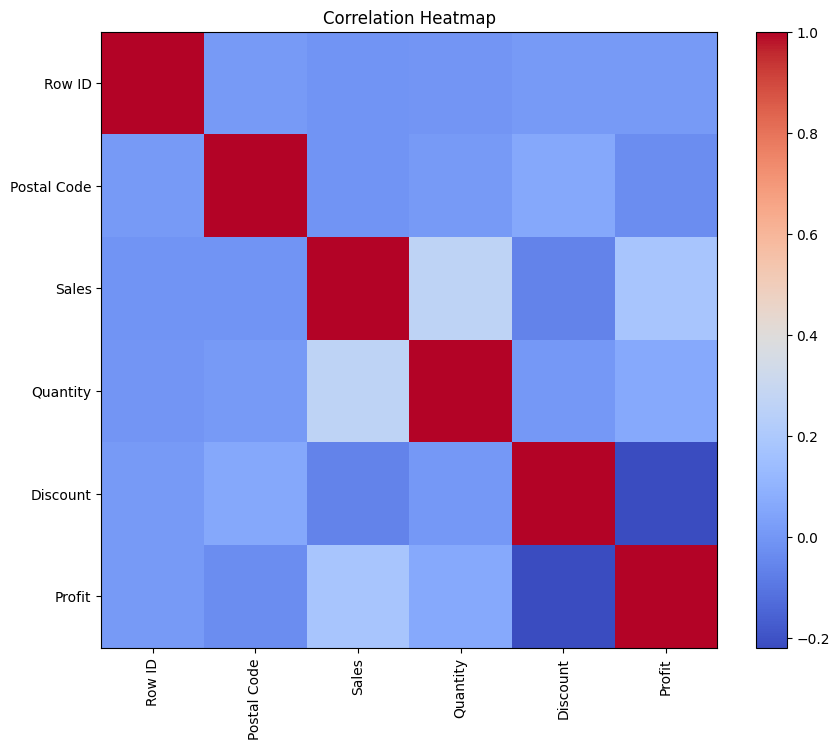

In [17]:
plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=90)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
high_sales = df[df["Sales"] > 500]

high_sales.head()
furniture = df[df["Category"] == "Furniture"]

furniture.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",498.93,3,0.00,219.5820
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,498.93,5,0.45,-383.0310
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7,0.00,14.1694
10,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,498.93,9,0.20,85.3092


In [19]:
df.sort_values(by="Sales", ascending=False).head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",498.93,3,0.00,219.5820
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,498.93,5,0.45,-383.0310
5771,5772,CA-2015-103835,9/24/2015,9/28/2015,Standard Class,SC-20440,Shaun Chance,Corporate,United States,Los Angeles,California,90032,West,OFF-AP-10002651,Office Supplies,Appliances,Hoover Upright Vacuum With Dirt Cup,498.93,4,0.00,335.8548
5772,5773,CA-2015-158939,11/26/2015,12/1/2015,Standard Class,EA-14035,Erin Ashbrook,Corporate,United States,Springfield,Missouri,65807,Central,TEC-CO-10002313,Technology,Copiers,Canon PC1080F Personal Copier,498.93,1,0.00,233.9961
5774,5775,CA-2016-142398,4/12/2016,4/16/2016,Standard Class,BP-11290,Beth Paige,Consumer,United States,Los Angeles,California,90036,West,FUR-CH-10001545,Furniture,Chairs,Hon Comfortask Task/Swivel Chairs,498.93,7,0.20,-31.9144
5753,5754,CA-2016-118514,2/3/2016,2/10/2016,Standard Class,LC-17050,Liz Carlisle,Consumer,United States,Richmond,Kentucky,40475,South,FUR-CH-10000015,Furniture,Chairs,Hon Multipurpose Stacking Arm Chairs,498.93,4,0.00,225.2640
5756,5757,CA-2014-163748,10/14/2014,10/18/2014,Standard Class,HG-15025,Hunter Glantz,Consumer,United States,Fort Worth,Texas,76106,Central,TEC-CO-10002095,Technology,Copiers,Hewlett Packard 610 Color Digital Copier / Pri...,498.93,5,0.20,624.9875
7683,7684,CA-2015-120782,4/28/2015,5/1/2015,First Class,SD-20485,Shirley Daniels,Home Office,United States,Midland,Michigan,48640,Central,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,498.93,3,0.00,1906.4850
7681,7682,CA-2014-133592,12/31/2014,1/7/2015,Standard Class,KM-16375,Katherine Murray,Home Office,United States,Providence,Rhode Island,2908,East,FUR-CH-10004218,Furniture,Chairs,"Global Fabric Manager's Chair, Dark Gray",498.93,6,0.00,151.4700
7679,7680,CA-2014-133592,12/31/2014,1/7/2015,Standard Class,KM-16375,Katherine Murray,Home Office,United States,Providence,Rhode Island,2908,East,TEC-AC-10002049,Technology,Accessories,Plantronics Savi W720 Multi-Device Wireless He...,498.93,4,0.00,742.6320


In [20]:
df.groupby("Category")["Sales"].sum()

,Sales
Category,
Furniture,480878.0084
Office Supplies,493104.0040
Technology,427987.3530


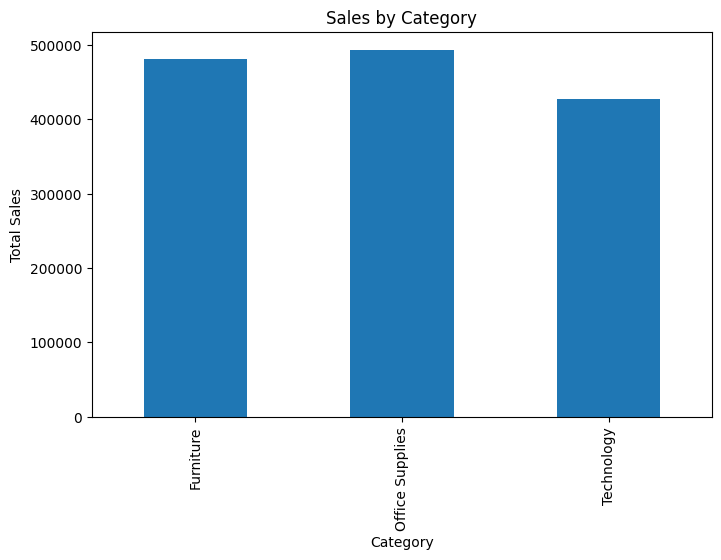

In [21]:
plt.figure(figsize=(8,5))

df.groupby("Category")["Sales"].sum().plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

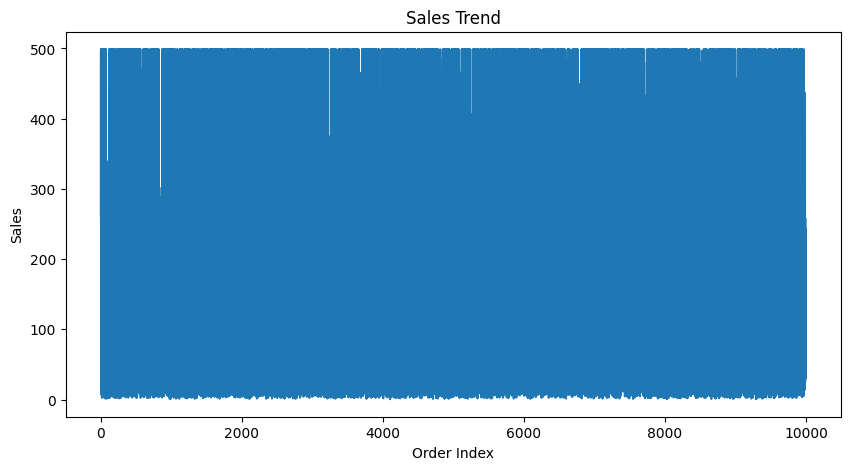

In [22]:
plt.figure(figsize=(10,5))

plt.plot(df["Sales"])

plt.title("Sales Trend")
plt.xlabel("Order Index")
plt.ylabel("Sales")

plt.show()

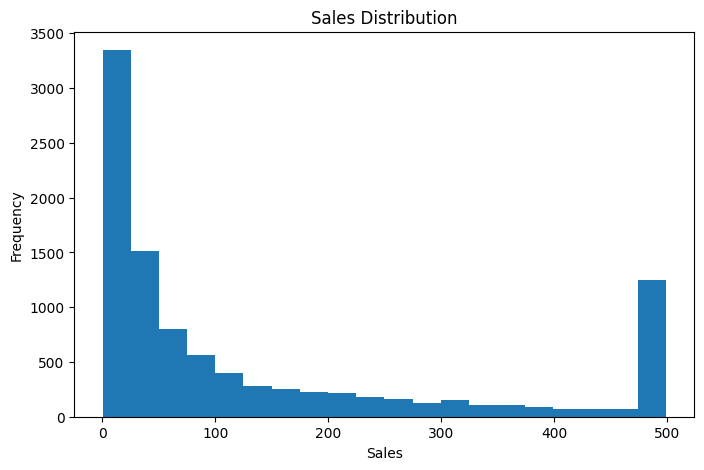

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=20)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

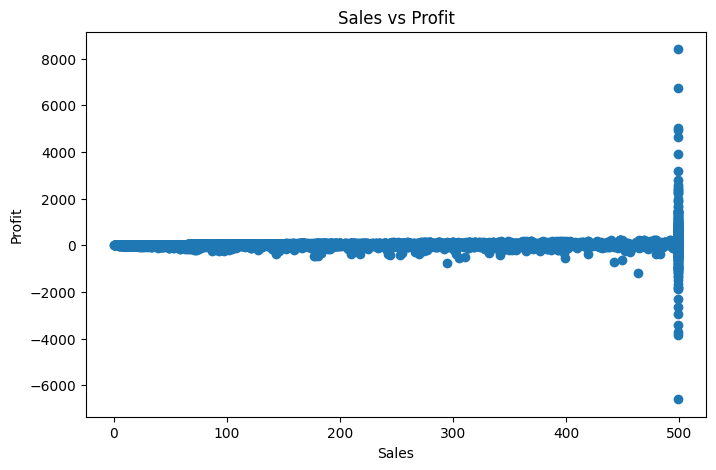

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()


# Retail Sales Analysis Dashboard

## Objective

Analyze retail sales data to identify sales trends, profit patterns, and business performance across categories and regions.

## Key Findings

- Technology generated the highest overall sales.
- Office Supplies contributed the largest number of orders.
- Some products with high sales resulted in negative profits due to discounts.
- Western and Eastern regions contributed significantly to overall profit.
- Furniture products had mixed profitability.

## Recommendations

- Reduce excessive discounts on low-profit products.
- Increase inventory for high-performing categories.
- Focus marketing efforts on profitable regions.
- Monitor products with high sales but low profit margins.